<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-TriTueNhanTaoNangCao_UngDung/blob/main/HuongDan_KMeans_SizeAo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-MEANS: Phân nhóm khách hàng theo chiều cao & cân nặng để gợi ý size áo

Bước 1: Tạo dữ liệu mô phỏng chiều cao — cân nặng khách hàng

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_moi_nhom = 60

In [2]:
# Nhóm khách hàng nhỏ con
chieu_cao_1 = np.random.normal(150, 4, n_moi_nhom)
can_nang_1 = np.random.normal(45, 4, n_moi_nhom)

In [3]:
# Nhóm khách hàng vừa
chieu_cao_2 = np.random.normal(160, 4, n_moi_nhom)
can_nang_2 = np.random.normal(56, 4, n_moi_nhom)

In [4]:
# Nhóm khách hàng lớn
chieu_cao_3 = np.random.normal(169, 4, n_moi_nhom)
can_nang_3 = np.random.normal(68, 4.5, n_moi_nhom)

In [5]:
# Nhóm khách hàng rất lớn
chieu_cao_4 = np.random.normal(178, 4, n_moi_nhom)
can_nang_4 = np.random.normal(83, 5, n_moi_nhom)

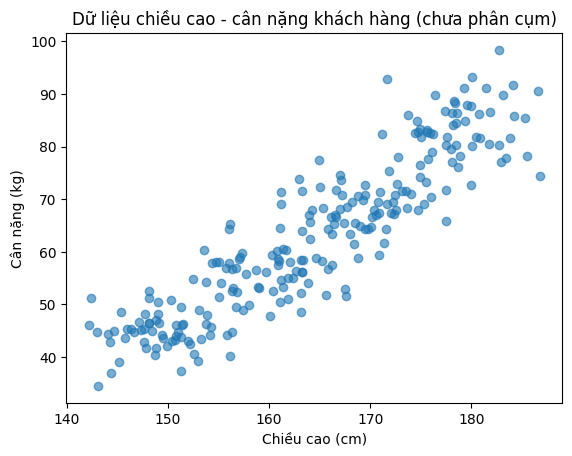

In [6]:
chieu_cao = np.concatenate([chieu_cao_1, chieu_cao_2, chieu_cao_3, chieu_cao_4])
can_nang = np.concatenate([can_nang_1, can_nang_2, can_nang_3, can_nang_4])

X = np.column_stack([chieu_cao, can_nang])

plt.scatter(X[:,0], X[:,1], alpha=0.6)
plt.xlabel('Chiều cao (cm)'); plt.ylabel('Cân nặng (kg)')
plt.title('Dữ liệu chiều cao - cân nặng khách hàng (chưa phân cụm)')
plt.show()

Bước 2: Dùng phương pháp Elbow để chọn số cụm K phù hợp

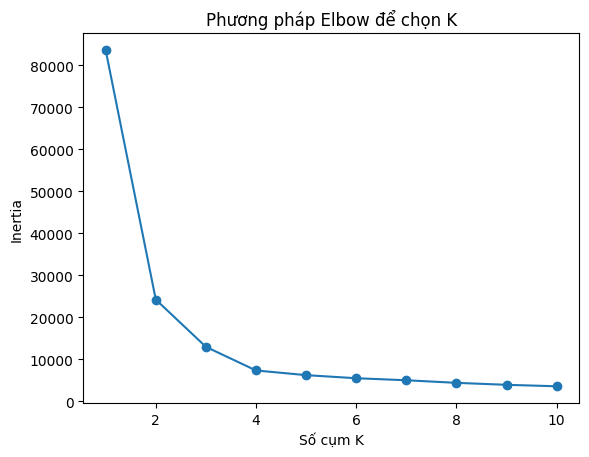

In [7]:
from sklearn.cluster import KMeans

inertia = []
dai_k = range(1, 11)
for k in dai_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(dai_k, inertia, marker='o')
plt.xlabel('Số cụm K'); plt.ylabel('Inertia')
plt.title('Phương pháp Elbow để chọn K')
plt.show()

Bước 3: Huấn luyện K-Means với K đã chọn và trực quan hóa kết quả

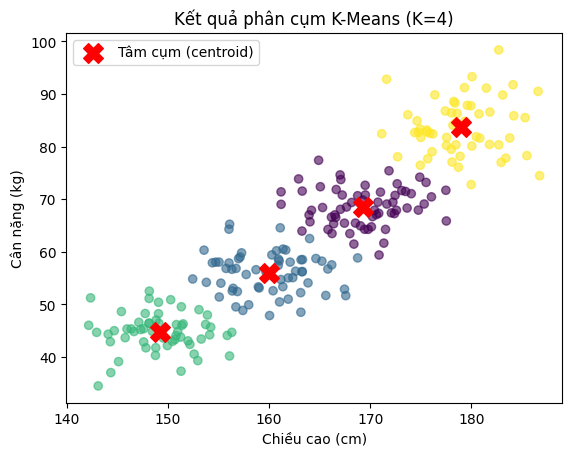

In [8]:
k_chon = 4
kmeans = KMeans(n_clusters=k_chon, random_state=42, n_init=10)
nhan_cum = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=nhan_cum, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c='red', marker='X', s=200, label='Tâm cụm (centroid)')
plt.xlabel('Chiều cao (cm)'); plt.ylabel('Cân nặng (kg)')
plt.title(f'Kết quả phân cụm K-Means (K={k_chon})')
plt.legend()
plt.show()

Bước 4: Đặt tên size (S/M/L/XL) có ý nghĩa cho từng cụm

In [9]:
tam_cum = kmeans.cluster_centers_
thu_tu_cum = np.argsort(tam_cum[:, 1])  # sắp xếp cụm theo cân nặng trung bình tăng dần

ten_size = ['S', 'M', 'L', 'XL']
cum_sang_size = {cum: ten_size[vi_tri] for vi_tri, cum in enumerate(thu_tu_cum)}

print('Đặc điểm trung bình mỗi cụm và size tương ứng:')
for cum in range(k_chon):
    print(f'Cụm {cum} -> Size {cum_sang_size[cum]}: '
          f'chiều cao TB = {tam_cum[cum,0]:.1f} cm, '
          f'cân nặng TB = {tam_cum[cum,1]:.1f} kg')

Đặc điểm trung bình mỗi cụm và size tương ứng:
Cụm 0 -> Size L: chiều cao TB = 169.3 cm, cân nặng TB = 68.6 kg
Cụm 1 -> Size M: chiều cao TB = 160.0 cm, cân nặng TB = 56.0 kg
Cụm 2 -> Size S: chiều cao TB = 149.2 cm, cân nặng TB = 44.7 kg
Cụm 3 -> Size XL: chiều cao TB = 178.9 cm, cân nặng TB = 83.7 kg


Bước 5: Trực quan hóa lại kết quả với nhãn size

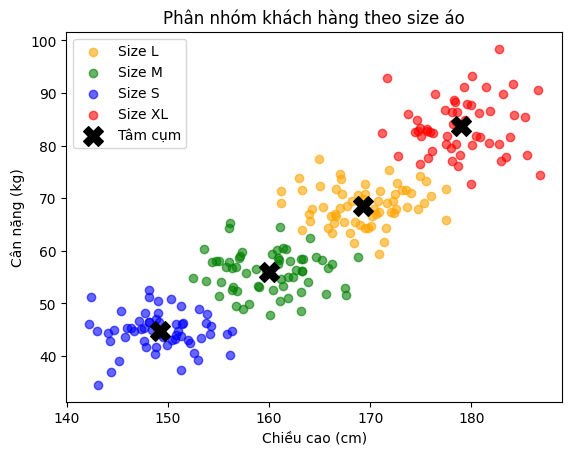

In [10]:
mau_sac = {'S': 'blue', 'M': 'green', 'L': 'orange', 'XL': 'red'}

for cum in range(k_chon):
    size = cum_sang_size[cum]
    plt.scatter(X[nhan_cum==cum, 0], X[nhan_cum==cum, 1],
                c=mau_sac[size], label=f'Size {size}', alpha=0.6)

plt.scatter(tam_cum[:,0], tam_cum[:,1], c='black', marker='X', s=200, label='Tâm cụm')
plt.xlabel('Chiều cao (cm)'); plt.ylabel('Cân nặng (kg)')
plt.title('Phân nhóm khách hàng theo size áo')
plt.legend()
plt.show()

Bước 6: Gợi ý size áo cho một khách hàng mới do người dùng nhập vào

In [11]:
print('=== GỢI Ý SIZE ÁO CHO KHÁCH HÀNG MỚI ===')
print("(Nhập 'q' ở bước nhập chiều cao để dừng)")

while True:
    nhap = input('\nNhập chiều cao (cm) — hoặc q để dừng: ')
    if nhap.strip().lower() == 'q':
        break
    chieu_cao_moi = float(nhap)
    can_nang_moi = float(input('Nhập cân nặng (kg): '))

    khach_moi = np.array([[chieu_cao_moi, can_nang_moi]])
    cum_du_doan = kmeans.predict(khach_moi)[0]
    size_goi_y = cum_sang_size[cum_du_doan]

    print(f'=> Size áo gợi ý: {size_goi_y}')

=== GỢI Ý SIZE ÁO CHO KHÁCH HÀNG MỚI ===
(Nhập 'q' ở bước nhập chiều cao để dừng)

Nhập chiều cao (cm) — hoặc q để dừng: 170
Nhập cân nặng (kg): 61
=> Size áo gợi ý: L

Nhập chiều cao (cm) — hoặc q để dừng: q


Bài tập mở rộng

Thử đổi K (ví dụ K=3 hoặc K=5) và quan sát các nhóm khách hàng cũng như cách gán size thay đổi ra sao.

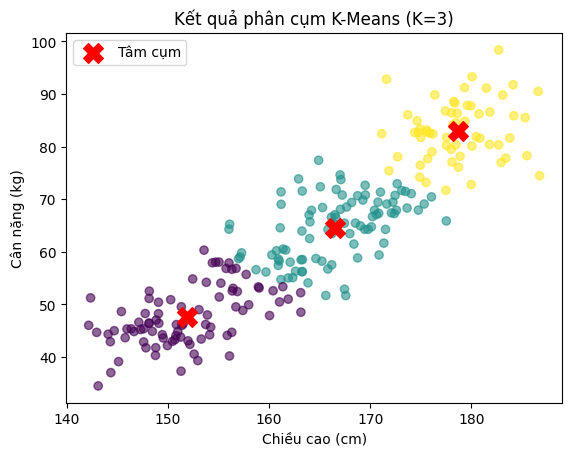

In [12]:
# Thử với K=3
k_chon = 3
kmeans = KMeans(n_clusters=k_chon, random_state=42, n_init=10)
nhan_cum = kmeans.fit_predict(X)

# Trực quan hóa
plt.scatter(X[:,0], X[:,1], c=nhan_cum, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c='red', marker='X', s=200, label='Tâm cụm')
plt.xlabel('Chiều cao (cm)')
plt.ylabel('Cân nặng (kg)')
plt.title(f'Kết quả phân cụm K-Means (K={k_chon})')
plt.legend()
plt.show()


Thêm đặc trưng thứ 3 (ví dụ: vòng ngực hoặc vòng eo mô phỏng) để phân cụm chính xác hơn

In [13]:
# Thêm đặc trưng vòng ngực (giả lập)
vong_nguc_1 = np.random.normal(80, 3, n_moi_nhom)   # nhóm nhỏ con
vong_nguc_2 = np.random.normal(88, 3, n_moi_nhom)   # nhóm vừa
vong_nguc_3 = np.random.normal(95, 3.5, n_moi_nhom) # nhóm lớn
vong_nguc_4 = np.random.normal(102, 4, n_moi_nhom)  # nhóm rất lớn

# Ghép thêm vào ma trận X
vong_nguc = np.concatenate([vong_nguc_1, vong_nguc_2, vong_nguc_3, vong_nguc_4])
X = np.column_stack([chieu_cao, can_nang, vong_nguc])

print(X.shape)  # giờ sẽ là (240, 3)


(240, 3)


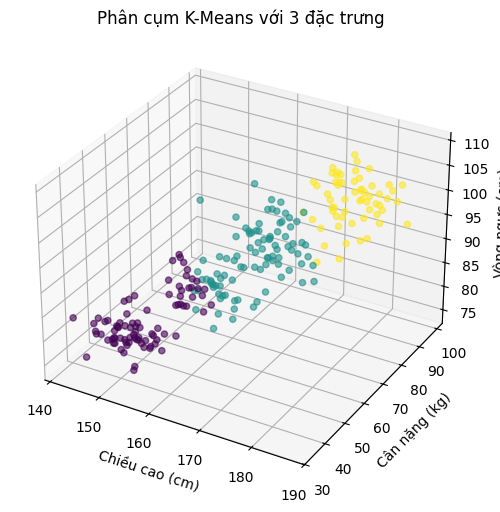

In [14]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=nhan_cum, cmap='viridis', alpha=0.6)
ax.set_xlabel('Chiều cao (cm)')
ax.set_ylabel('Cân nặng (kg)')
ax.set_zlabel('Vòng ngực (cm)')
plt.title('Phân cụm K-Means với 3 đặc trưng')
plt.show()


So sánh cách gán size bằng K-Means với cách truyền thống — chỉ dựa vào một mốc chiều cao duy nhất (ví dụ dưới 160cm là S, 160–168cm là M...) — nhận xét ưu/nhược điểm của từng cách

**K-Means clustering**

**Ưu điểm:**









*   Xem xét nhiều đặc trưng cùng lúc (chiều cao, cân nặng, thậm chí vòng ngực/vòng eo nếu thêm), nên phản ánh vóc dáng tổng thể chính xác hơn.
*   Tự động tìm ra các nhóm tự nhiên trong dữ liệu, không bị giới hạn bởi quy tắc cứng nhắc.
* Linh hoạt: có thể mở rộng thêm đặc trưng khác mà không cần thay đổi logic gán size.

* Giúp phát hiện những khách hàng “ngoại lệ” (ví dụ cao nhưng nhẹ cân) mà cách truyền thống dễ bỏ sót.


**Nhược điểm:**

* Kết quả phụ thuộc vào dữ liệu huấn luyện: nếu dữ liệu không đủ đa dạng, cụm có thể bị lệch.

* Cần tính toán và trực quan hóa, phức tạp hơn so với quy tắc đơn giản.

* Không đảm bảo khớp hoàn toàn với size chuẩn của ngành thời trang (chỉ mang tính minh họa).



**Quy tắc truyền thống (dựa vào chiều cao duy nhất)**

**Ưu điểm:**

* Rất đơn giản, dễ áp dụng ngay mà không cần mô hình hay dữ liệu.

* Dễ giải thích cho khách hàng: chỉ cần nhìn vào chiều cao là biết size.

* Phù hợp trong trường hợp không có dữ liệu hoặc không muốn dùng thuật toán.

**Nhược điểm:**

* Thiếu chính xác: bỏ qua cân nặng và các yếu tố khác, dẫn đến gợi ý sai cho những người có cùng chiều cao nhưng vóc dáng khác nhau.

* Không linh hoạt: khó mở rộng thêm đặc trưng khác.

* Có thể gây trải nghiệm không tốt cho khách hàng (ví dụ người cao 165cm nhưng nặng 80kg vẫn bị gán size M theo quy tắc chiều cao).

Nhận xét tổng thể:

* **K-Means** phù hợp khi bạn có dữ liệu và muốn gợi ý size sát thực tế hơn, đặc biệt khi vóc dáng đa dạng.

* **Quy tắc truyền thống** chỉ nên dùng như một cách nhanh, đơn giản, nhưng độ chính xác thấp.

Thử chuẩn hóa dữ liệu bằng StandardScaler trước khi phân cụm (vì chiều cao và cân nặng có thang đo khác nhau) và so sánh kết quả trước/sau chuẩn hóa.

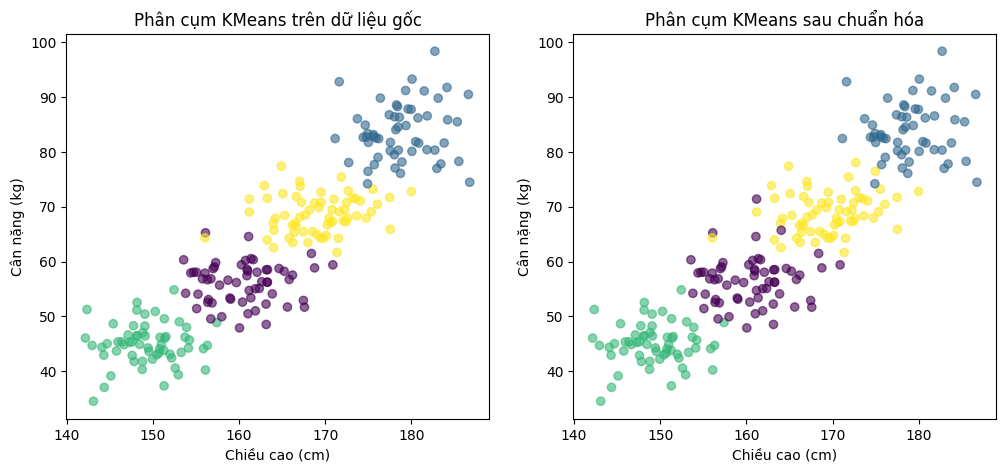

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # X là ma trận chiều cao - cân nặng

# Huấn luyện KMeans với dữ liệu gốc
kmeans_raw = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(X)

# Huấn luyện KMeans với dữ liệu đã chuẩn hóa
kmeans_scaled = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

# So sánh trực quan
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c=labels_raw, cmap='viridis', alpha=0.6)
plt.title("Phân cụm KMeans trên dữ liệu gốc")
plt.xlabel("Chiều cao (cm)")
plt.ylabel("Cân nặng (kg)")

plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], c=labels_scaled, cmap='viridis', alpha=0.6)
plt.title("Phân cụm KMeans sau chuẩn hóa")
plt.xlabel("Chiều cao (cm)")
plt.ylabel("Cân nặng (kg)")

plt.show()


Nhận xét khi so sánh:
* Trước chuẩn hóa: cụm thường bị lệch theo chiều cao vì giá trị cm lớn hơn, khiến cân nặng ít ảnh hưởng.

* Sau chuẩn hóa: cả chiều cao và cân nặng đều được đưa về cùng thang đo (trung bình = 0, độ lệch chuẩn = 1), nên mô hình phân cụm cân bằng hơn, phản ánh vóc dáng tổng thể chính xác hơn.

**Kết quả** : chuẩn hóa giúp mô hình không thiên vị đặc trưng nào, và cụm được phân chia hợp lý hơn.